# Latin Square Rules: DiT Learning Analysis

**Rule**: An n×n grid where each integer 1..n appears exactly once in every row and every column (Latin square).

**Encodings**:
- *scalar*: integer values 1..n encoded directly as floats (or normalized scalars)
- *onehot (zeromean)*: each cell is a zero-mean one-hot vector of length n

**Models and grid sizes**:
| Exp | Model | n | Encoding |
|---|---|---|---|
| mini-n5-scalar | DiT-mini | 5×5 | scalar |
| mini-n6-scalar | DiT-mini | 6×6 | scalar |
| mini-n5-onehot | DiT-mini | 5×5 | onehot |
| mini-n6-onehot | DiT-mini | 6×6 | onehot (zeromean autoSD) |
| B-n5-scalar | DiT-B | 5×5 | scalar |
| B-n6-scalar | DiT-B | 6×6 | scalar |

**Analysis sections**:
1. Training curves (loss, valid, row/col valid, mem, nan_ratio)
2. Encoding comparison: onehot vs scalar (n5 and n6)
3. Model size comparison: DiT-mini vs DiT-B
4. Valid/Mem overlay — memorization onset per variant
5. Crash correlation: late-training mem rise

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIGDIR   = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/latinsq_analysis"
SAVE_FIGS = True
os.makedirs(FIGDIR, exist_ok=True)

%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 120

# ── Experiment registry ─────────────────────────────────────────────────────
EXPS = [
    ('mini-n5-scalar', 'DiT_mini_latinSq_n5_N4096_scalar',                 '#1f77b4', '-'),
    ('mini-n6-scalar', 'DiT_mini_latinSq_n6_N4096_scalar',                 '#aec7e8', '-'),
    ('mini-n5-onehot', 'DiT_mini_latinSq_n5_N4096_onehot',                 '#ff7f0e', '--'),
    ('mini-n6-onehot', 'DiT_mini_latinSq_n6_N4096_onehot_zeromean_autoSD', '#ffbb78', '--'),
    ('B-n5-scalar',    'DiT_B_latinSq_n5_N4096_scalar',                    '#2ca02c', ':'),
    ('B-n6-scalar',    'DiT_B_latinSq_n6_N4096_scalar',                    '#98df8a', ':'),
]
LABELS    = [e[0] for e in EXPS]
EXP_NAMES = [e[1] for e in EXPS]
COLORS    = {e[0]: e[2] for e in EXPS}
LSTYLES   = {e[0]: e[3] for e in EXPS}

def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ['png', 'pdf']:
            fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=150, bbox_inches='tight')

def ema_smooth(arr, alpha=0.9):
    if len(arr) == 0: return arr
    s = np.zeros_like(arr, dtype=np.float32)
    s[0] = arr[0]
    for i in range(1, len(arr)):
        s[i] = (1 - alpha) * arr[i] + alpha * s[i-1]
    return s

print("Experiments:")
for lbl, exp, c, ls in EXPS:
    ok = os.path.isdir(os.path.join(SAVEROOT, exp))
    print(f"  {'✓' if ok else '✗'} {lbl:20s}  {exp}")

Experiments:
  ✓ mini-n5-scalar        DiT_mini_latinSq_n5_N4096_scalar
  ✓ mini-n6-scalar        DiT_mini_latinSq_n6_N4096_scalar
  ✓ mini-n5-onehot        DiT_mini_latinSq_n5_N4096_onehot
  ✓ mini-n6-onehot        DiT_mini_latinSq_n6_N4096_onehot_zeromean_autoSD
  ✓ B-n5-scalar           DiT_B_latinSq_n5_N4096_scalar
  ✓ B-n6-scalar           DiT_B_latinSq_n6_N4096_scalar


In [2]:
def load_tb(exp_name, tags=None):
    tb_dir = os.path.join(SAVEROOT, exp_name, 'tensorboard')
    ea = EventAccumulator(tb_dir, size_guidance={'scalars': 0})
    ea.Reload()
    available = ea.Tags()['scalars']
    if tags is None: tags = available
    result = {}
    for tag in tags:
        if tag in available:
            events = ea.Scalars(tag)
            result[tag] = {
                'steps': np.array([e.step  for e in events]),
                'vals':  np.array([e.value for e in events]),
            }
    return result

TAGS = ['train/loss', 'eval/full_valid_ratio', 'eval/row_valid_ratio',
        'eval/col_valid_ratio', 'eval/sample_mem_ratio',
        'eval/nan_ratio_permissive', 'eval/nan_ratio_strict']

tb_data = {}
for lbl, exp, _, _ in EXPS:
    try:
        tb_data[lbl] = load_tb(exp, TAGS)
        last = tb_data[lbl]['train/loss']['steps'][-1]
        print(f"{lbl:20s}: loaded  (last step={last:,})")
    except Exception as e:
        print(f"{lbl:20s}: ERROR — {e}")
        tb_data[lbl] = {}

mini-n5-scalar      : loaded  (last step=1,000,000)


mini-n6-scalar      : loaded  (last step=1,000,000)


mini-n5-onehot      : loaded  (last step=1,000,000)


mini-n6-onehot      : loaded  (last step=1,000,000)


B-n5-scalar         : loaded  (last step=1,000,000)


B-n6-scalar         : loaded  (last step=1,000,000)


## 1. Training curves — all variants

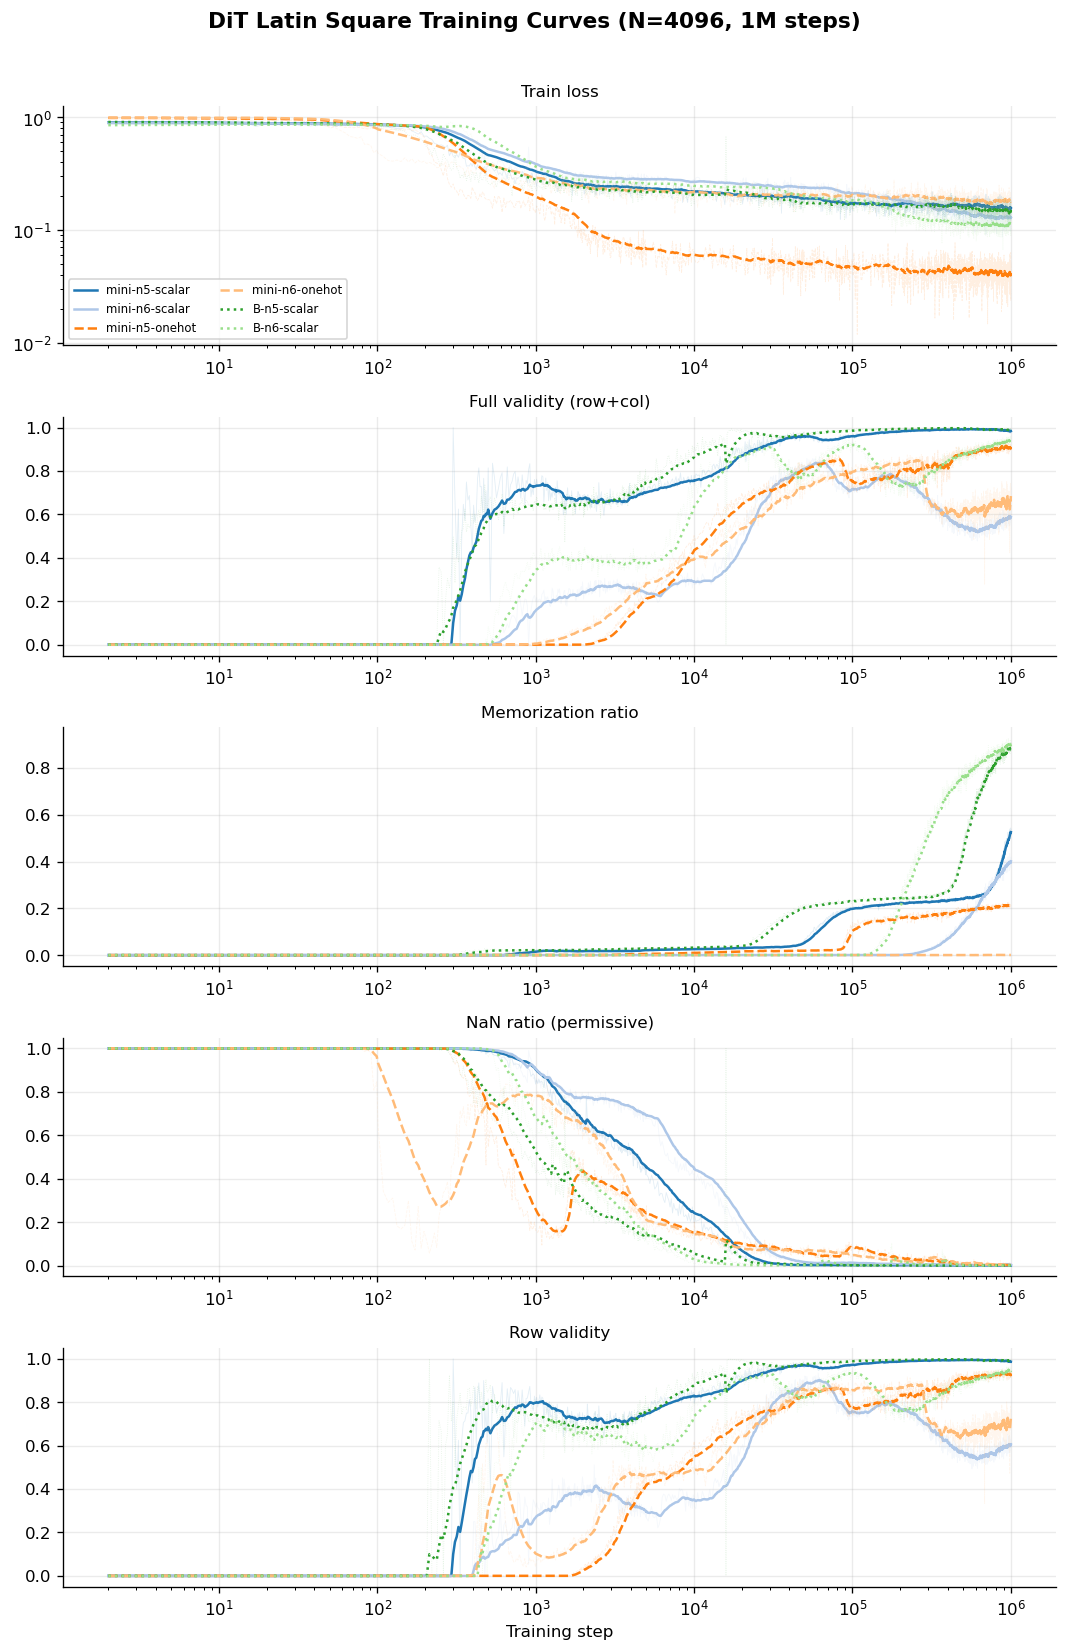

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(9, 14), sharex=True)
fig.suptitle("DiT Latin Square Training Curves (N=4096, 1M steps)",
             fontsize=13, fontweight='bold')

panels = [
    ('train/loss',              axes[0], 'Train loss',              True,  0.95),
    ('eval/full_valid_ratio',   axes[1], 'Full validity (row+col)', False, 0.9),
    ('eval/sample_mem_ratio',   axes[2], 'Memorization ratio',      False, 0.9),
    ('eval/nan_ratio_permissive',axes[3],'NaN ratio (permissive)',   False, 0.9),
    ('eval/row_valid_ratio',    axes[4], 'Row validity',             False, 0.9),
]

for tag, ax, title, logy, alpha in panels:
    for lbl in LABELS:
        d = tb_data[lbl].get(tag)
        if d is None: continue
        c  = COLORS[lbl]
        ls = LSTYLES[lbl]
        ax.plot(d['steps']+1, d['vals'], color=c, lw=0.5, alpha=0.12, ls=ls)
        ax.plot(d['steps']+1, ema_smooth(d['vals'], alpha), color=c,
                lw=1.5, ls=ls, label=lbl)
    ax.set_xscale('log')
    if logy: ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', labelbottom=True)

axes[0].legend(loc='lower left', fontsize=7, ncol=2)
axes[-1].set_xlabel('Training step', fontsize=10)
plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'training_curves')
plt.show()

## 2. Encoding comparison: onehot vs scalar (same n, same model)

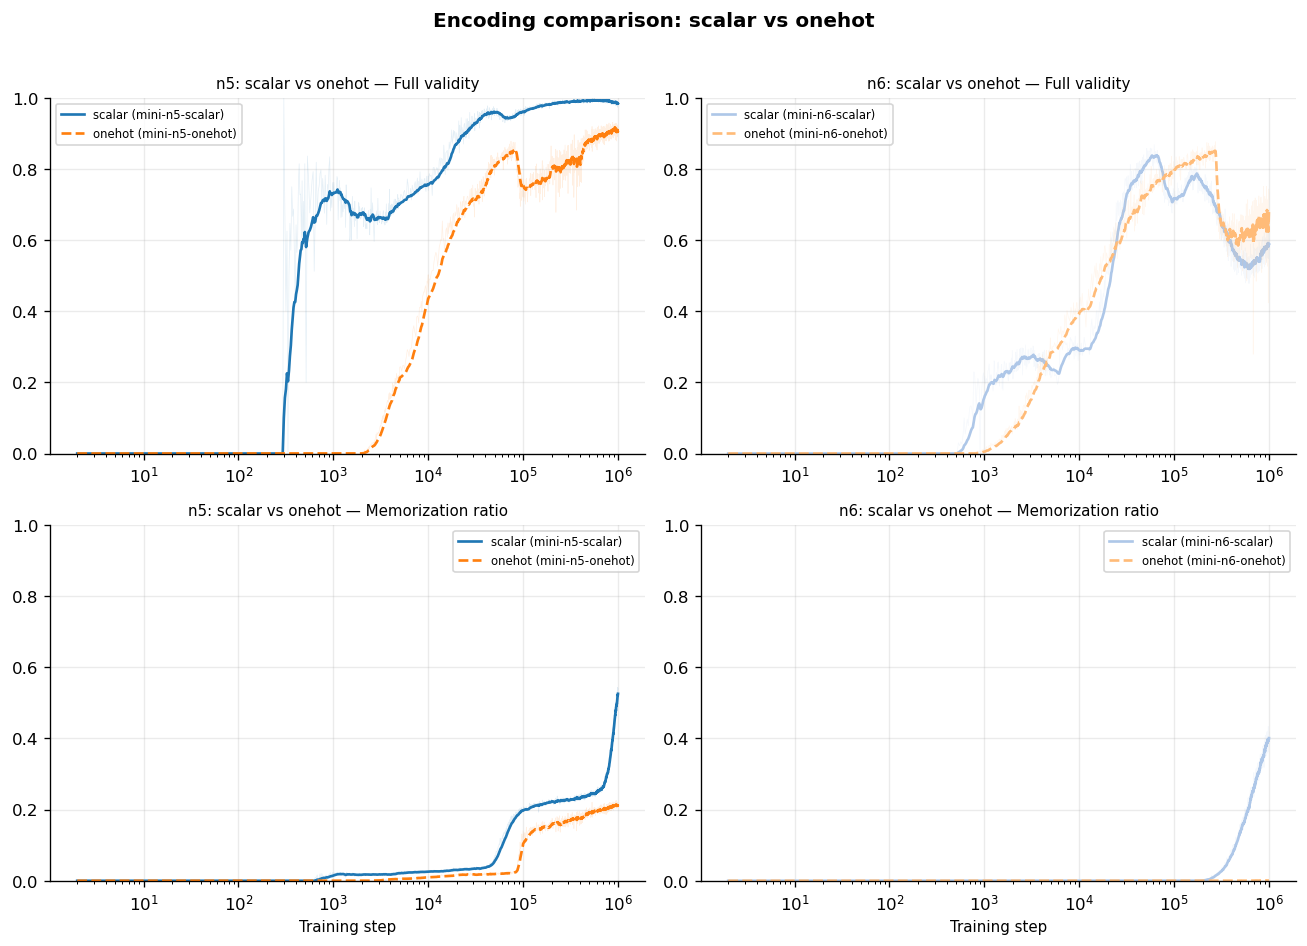

In [4]:
# Compare onehot vs scalar for n=5 (mini) and n=6 (mini)
PAIRS = [
    ('n5: scalar vs onehot', 'mini-n5-scalar', 'mini-n5-onehot'),
    ('n6: scalar vs onehot', 'mini-n6-scalar', 'mini-n6-onehot'),
]
METRICS = [
    ('eval/full_valid_ratio', 'Full validity'),
    ('eval/sample_mem_ratio', 'Memorization ratio'),
]

fig, axes = plt.subplots(len(METRICS), len(PAIRS), figsize=(11, 4*len(METRICS)), sharex=True)
fig.suptitle("Encoding comparison: scalar vs onehot", fontsize=12, fontweight='bold')

for ci, (pair_title, lbl_s, lbl_o) in enumerate(PAIRS):
    for ri, (tag, metric_title) in enumerate(METRICS):
        ax = axes[ri][ci]
        for lbl, enc_label in [(lbl_s, 'scalar'), (lbl_o, 'onehot')]:
            d = tb_data[lbl].get(tag)
            if d is None: continue
            c  = COLORS[lbl]
            ls = LSTYLES[lbl]
            ax.plot(d['steps']+1, d['vals'], color=c, lw=0.4, alpha=0.12)
            ax.plot(d['steps']+1, ema_smooth(d['vals'], 0.9), color=c,
                    lw=1.6, ls=ls, label=f"{enc_label} ({lbl})")
        ax.set_xscale('log')
        ax.set_ylim(0, 1)
        ax.set_title(f"{pair_title} — {metric_title}", fontsize=9)
        ax.grid(alpha=0.25)
        ax.tick_params(axis='x', which='both', labelbottom=True)
        ax.legend(fontsize=7)

axes[-1][0].set_xlabel('Training step', fontsize=9)
axes[-1][1].set_xlabel('Training step', fontsize=9)
plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'encoding_comparison')
plt.show()

## 3. Model size comparison: DiT-mini vs DiT-B (scalar encoding)

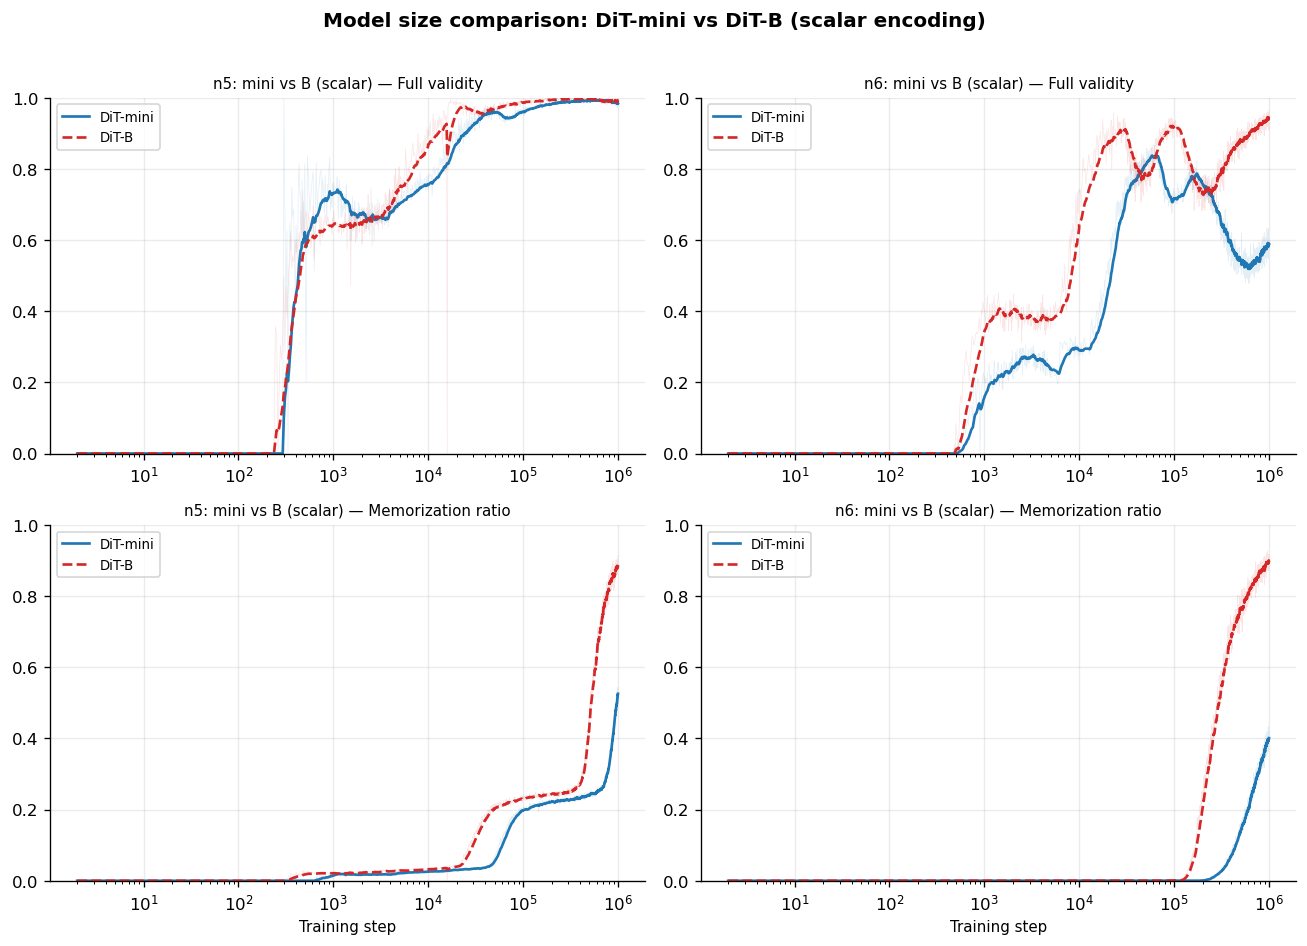

In [5]:
MODEL_PAIRS = [
    ('n5: mini vs B (scalar)', 'mini-n5-scalar', 'B-n5-scalar'),
    ('n6: mini vs B (scalar)', 'mini-n6-scalar', 'B-n6-scalar'),
]

fig, axes = plt.subplots(len(METRICS), len(MODEL_PAIRS), figsize=(11, 4*len(METRICS)), sharex=True)
fig.suptitle("Model size comparison: DiT-mini vs DiT-B (scalar encoding)",
             fontsize=12, fontweight='bold')

MODEL_COLORS = {'mini': '#1f77b4', 'B': '#d62728'}
MODEL_LS     = {'mini': '-',       'B': '--'}

for ci, (pair_title, lbl_mini, lbl_B) in enumerate(MODEL_PAIRS):
    for ri, (tag, metric_title) in enumerate(METRICS):
        ax = axes[ri][ci]
        for lbl, model_key in [(lbl_mini, 'mini'), (lbl_B, 'B')]:
            d = tb_data[lbl].get(tag)
            if d is None: continue
            c  = MODEL_COLORS[model_key]
            ls = MODEL_LS[model_key]
            ax.plot(d['steps']+1, d['vals'], color=c, lw=0.4, alpha=0.12)
            ax.plot(d['steps']+1, ema_smooth(d['vals'], 0.9), color=c,
                    lw=1.6, ls=ls, label=f"DiT-{model_key}")
        ax.set_xscale('log')
        ax.set_ylim(0, 1)
        ax.set_title(f"{pair_title} — {metric_title}", fontsize=9)
        ax.grid(alpha=0.25)
        ax.tick_params(axis='x', which='both', labelbottom=True)
        ax.legend(fontsize=8)

axes[-1][0].set_xlabel('Training step', fontsize=9)
axes[-1][1].set_xlabel('Training step', fontsize=9)
plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'model_size_comparison')
plt.show()

## 4. Valid / Mem overlay — memorization onset

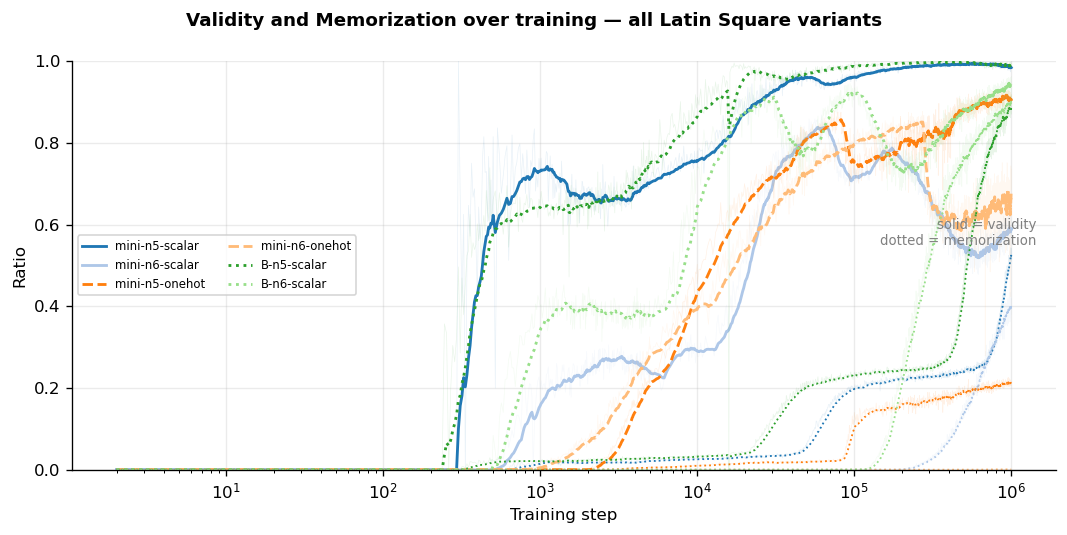

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.suptitle("Validity and Memorization over training — all Latin Square variants",
             fontsize=11, fontweight='bold')

for lbl in LABELS:
    v = tb_data[lbl].get('eval/full_valid_ratio')
    m = tb_data[lbl].get('eval/sample_mem_ratio')
    c  = COLORS[lbl]
    ls = LSTYLES[lbl]
    if v is not None:
        ax.plot(v['steps']+1, v['vals'], color=c, lw=0.4, alpha=0.1)
        ax.plot(v['steps']+1, ema_smooth(v['vals'], 0.9), color=c,
                lw=1.7, ls=ls, label=lbl)
    if m is not None:
        ax.plot(m['steps']+1, m['vals'], color=c, lw=0.4, alpha=0.1)
        ax.plot(m['steps']+1, ema_smooth(m['vals'], 0.9), color=c,
                lw=1.1, ls=':')

ax.set_xscale('log')
ax.set_ylim(0, 1)
ax.set_xlabel('Training step', fontsize=10)
ax.set_ylabel('Ratio', fontsize=10)
ax.text(0.98, 0.55, 'solid = validity\ndotted = memorization',
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')
ax.legend(fontsize=7, ncol=2, loc='center left')
ax.grid(alpha=0.25)
plt.tight_layout()
savefig(fig, 'valid_mem_overlay')
plt.show()

## 5. Crash correlation: late-training zoom

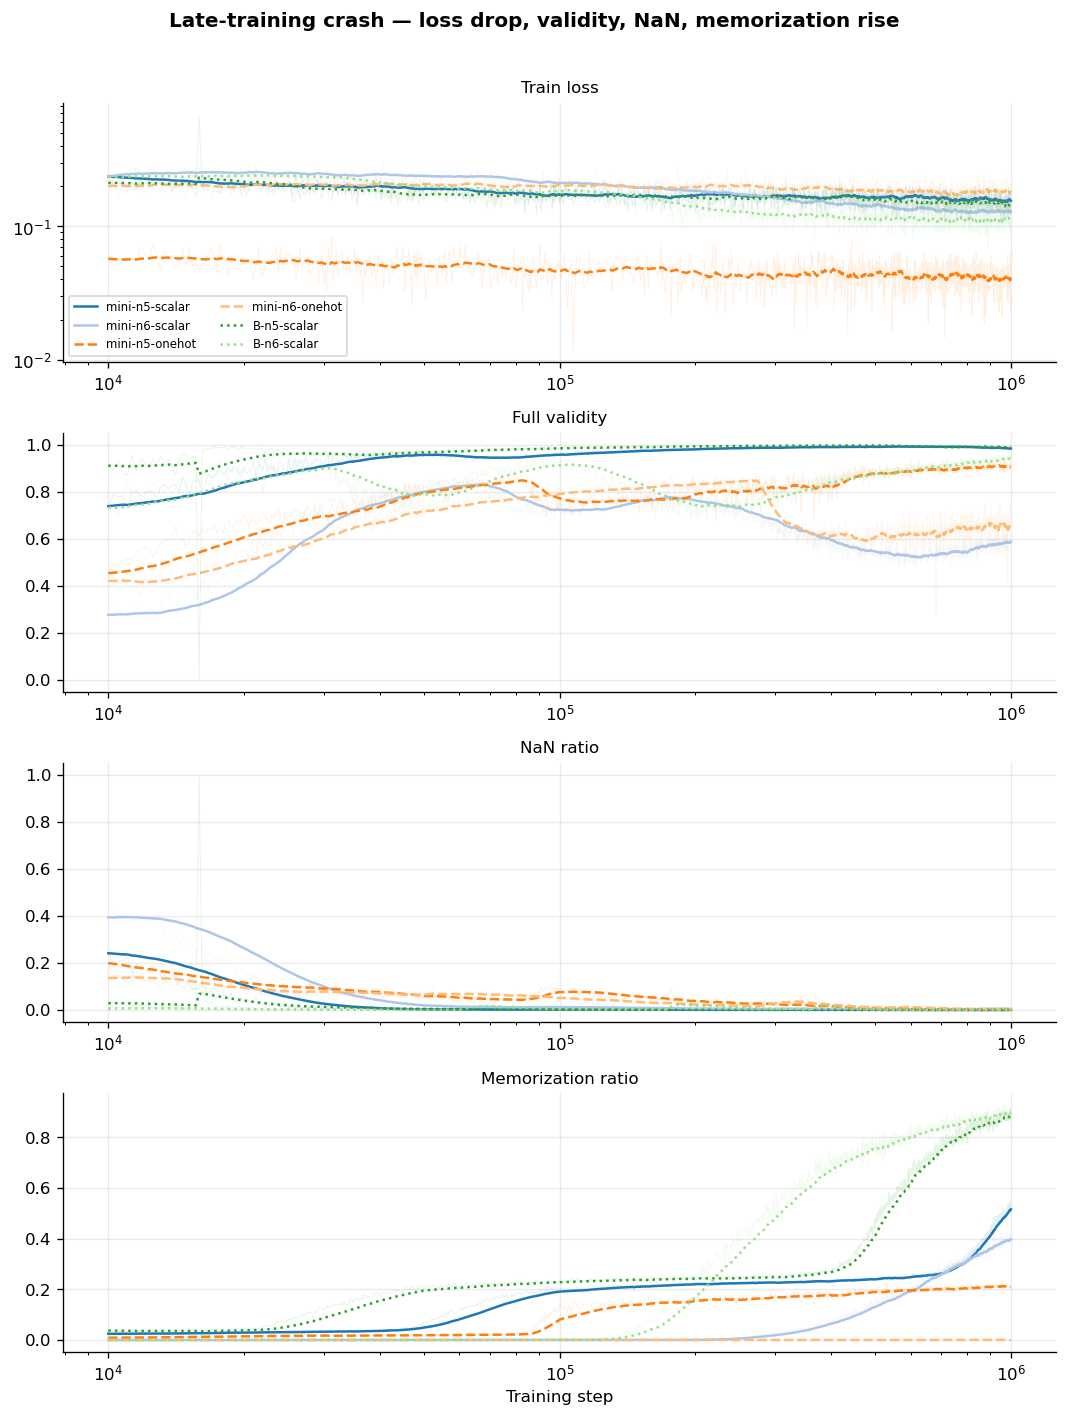

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)
fig.suptitle("Late-training crash — loss drop, validity, NaN, memorization rise",
             fontsize=12, fontweight='bold')

panels_crash = [
    ('train/loss',              axes[0], 'Train loss',              True,  0.95),
    ('eval/full_valid_ratio',   axes[1], 'Full validity',           False, 0.95),
    ('eval/nan_ratio_permissive',axes[2],'NaN ratio',               False, 0.95),
    ('eval/sample_mem_ratio',   axes[3], 'Memorization ratio',      False, 0.95),
]

STEP_MIN = 1e4
for tag, ax, title, logy, alpha in panels_crash:
    for lbl in LABELS:
        d = tb_data[lbl].get(tag)
        if d is None: continue
        mask = d['steps'] >= STEP_MIN
        if not mask.any(): continue
        steps = d['steps'][mask] + 1
        vals  = d['vals'][mask]
        c  = COLORS[lbl]
        ls = LSTYLES[lbl]
        ax.plot(steps, vals, color=c, lw=0.5, alpha=0.12)
        ax.plot(steps, ema_smooth(vals, alpha), color=c, lw=1.5, ls=ls, label=lbl)
    ax.set_xscale('log')
    if logy: ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', labelbottom=True)

axes[0].legend(loc='lower left', fontsize=7, ncol=2)
axes[-1].set_xlabel('Training step', fontsize=10)
plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'crash_correlation_zoom')
plt.show()

## 6. Final metrics summary

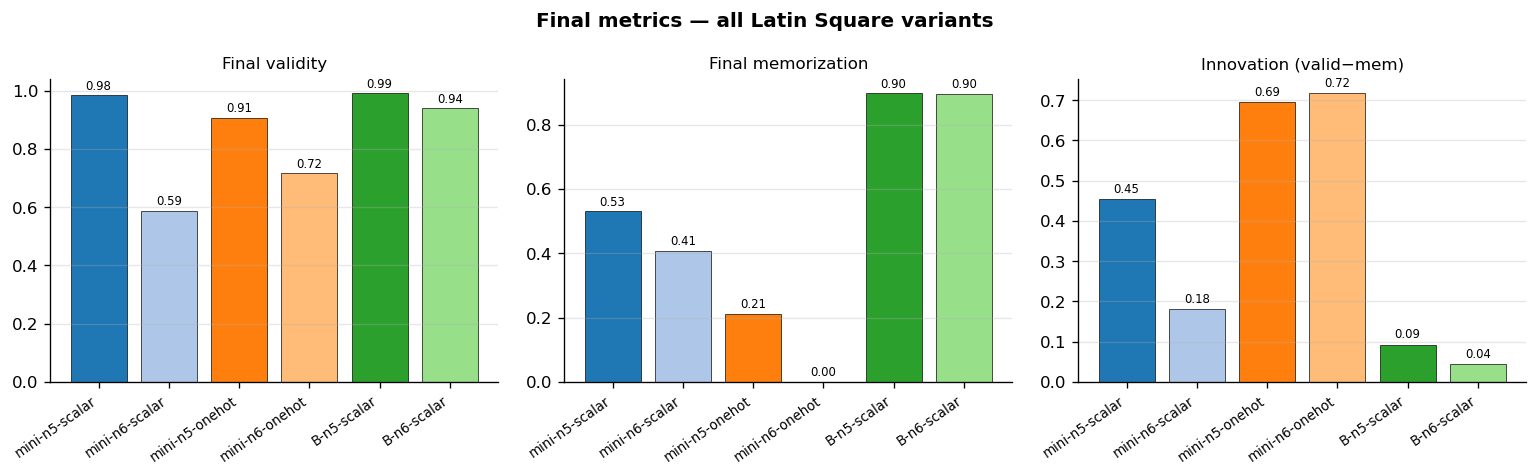

Run                       valid      mem    innov
mini-n5-scalar            0.984    0.530    0.453
mini-n6-scalar            0.588    0.407    0.181
mini-n5-onehot            0.907    0.212    0.694
mini-n6-onehot            0.717    0.001    0.717
B-n5-scalar               0.991    0.897    0.093
B-n6-scalar               0.939    0.895    0.044


In [8]:
def final_val(lbl, tag, n_avg=5):
    d = tb_data[lbl].get(tag)
    if d is None or len(d['vals']) == 0: return np.nan
    return float(d['vals'][-n_avg:].mean())

valid_f = [final_val(l, 'eval/full_valid_ratio') for l in LABELS]
mem_f   = [final_val(l, 'eval/sample_mem_ratio') for l in LABELS]
innov_f = [v - m for v, m in zip(valid_f, mem_f)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Final metrics — all Latin Square variants", fontsize=12, fontweight='bold')
x = np.arange(len(LABELS))
colors = [COLORS[l] for l in LABELS]

for ax, (ys, title) in zip(axes, [
        (valid_f, 'Final validity'), (mem_f, 'Final memorization'), (innov_f, 'Innovation (valid−mem)')]):
    bars = ax.bar(x, ys, color=colors, edgecolor='k', lw=0.4)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, ys):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, max(bar.get_height(), 0)+0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
savefig(fig, 'final_metrics')
plt.show()

print(f"{'Run':22s}  {'valid':>7}  {'mem':>7}  {'innov':>7}")
for l, v, m, iv in zip(LABELS, valid_f, mem_f, innov_f):
    print(f"{l:22s}  {v:7.3f}  {m:7.3f}  {iv:7.3f}")